## MT 1D FORWARD MODELING PROGRAM

Complete the missing portions of the code below (**...**) to create your own modelling program!

First import the tools that you need to run the program.


Import the required libraries cmath and math. The math library contains real number mathematical functions and contains the same functions found in the ANSI c library. The cmath library contains mathematical functions for complex number calculation.

In [44]:
import numpy as np
import math
import cmath

Initialize constants. mu is the Magnetic Permeability (H/m) and is only computed once at the start of the program.

In [45]:
mu = 4*math.pi*1E-7; #Magnetic Permeability (H/m)
print("This is the magnetic permeability: " + str(mu))

This is the magnetic permeability: 1.2566370614359173e-06


Below is the equation linking the impedance to the resistivity:

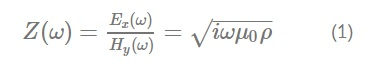

How does the impedance vary with frequency?

Consider a medium of resistivity 2500 Ohm.m.
Using equation 1, compute the impedance of this medium at a frequency of 100Hz.

In [46]:
### First specify the resistivity of the current layer:
resistivity = 2500
### Then specify the frequency:
frequency = 100
### Then compute the pulsation:
w = 2 * math.pi * frequency    
### Then compute the impedance. You can use cmath.sqrt function for the square root; 1j is the imaginary number:
impedance = cmath.sqrt(w * mu * resistivity * 1j)
print(impedance)

(0.99345882657961+0.9934588265796102j)


What can you say about the computed impedance? Is it real or complex valued?

Now let's assume that this 2500 Ohm.m layer is overlain by a more resistive layer of resistivity 3000 Ohm.m and of thickness 500m. How can we compute the impedance of this overlying layer?

In [47]:
### First enter the value that you just computed for the half-space in the belowImpedance parameter:
belowImpedance = impedance
resistivity = 3000
thickness = 500

### Now compute the induction parameter:
dj = cmath.sqrt(w * mu * 1/resistivity * 1j)

### Compute the intrinsic impedance:
wj = dj * resistivity 

### Calculate Exponential factor from intrinsic impedance
ej = cmath.exp(-2*thickness*dj)                     
    
### Calculate reflection coeficient using current layer intrinsic impedance and the below layer impedance

rj = (wj - belowImpedance) / (wj + belowImpedance)
re = rj * ej
Zj = (1 - re) / (1 + re)

SyntaxError: invalid syntax (<ipython-input-47-52ccb2221317>, line 19)

Now turn the code in the cell above into a function, called **compute_impedance_from_impedance_of_underlying_layer**. Which arguments should this function take? If you have never written a function into Python, check out the cell below:

In [2]:
def this_is_a_function(this_is_a_string):
  print(this_is_a_string)
  return

this_is_a_function("Hello UFAZ")

Hello UFAZ


In [11]:
def compute_impedance_from_impedance_of_underlying_layer(belowImpedance, resistivity, thickness):

  ### Now compute the induction parameter:
  dj = cmath.sqrt(1j * w * mu * (1/resistivity))

  ### Compute the intrinsic impedance:
  wj = dj * resistivity

  ### Calculate Exponential factor from intrinsic impedance
  ej = cmath.exp(-2*thickness*dj)

  ### Calculate reflection coeficient using current layer intrinsic impedance and the below layer impedance

  rj = (wj - belowImpedance)/(wj + belowImpedance)
  re = rj*ej
  Zj = wj * ((1-re)/(1+re))

  return Zj

compute_impedance_from_impedance_of_underlying_layer(belowImpedance, resistivity, thickness)

(1.00230959887569+1.048480935837602j)

Now create a 5 layers model, whose resistivities are, from top to bottom: 300, 2500, 0.8, 3000 and 2500 Ohm.m, and whose thicknesses are: 200, 400, 40 and 500 m.  FYI, the program will accept any number of layers, but you must ensure that if N is the number of resistivities, the thicknesses array must have N-1 elements

In [17]:
resistivities=[300, 2500, 0.8, 3000, 2500]
thicknesses=[200, 400, 40, 500]
n=len(resistivities)

Let's write a function to compute the impedance for each layer, for a given frequency:

In [26]:
def compute_apparent_resistivity_and_phase(frequency):
    w = 2*math.pi*frequency
    impedances = list(range(n))
    #compute basement impedance
    impedances[n-1] = cmath.sqrt(w*mu*resistivities[n-1]*1j);

    for j in range(n-2,-1,-1):
        resistivity = resistivities[j]
        thickness = thicknesses[j]

        # 3. Compute apparent resistivity from top layer impedance
        #Step 2. Iterate from bottom layer to top(not the basement)
        # Step 2.1 Calculate the intrinsic impedance of current layer
        dj = cmath.sqrt((w * mu * (1.0/resistivity))*1j)
        wj = dj * resistivity
        # Step 2.2 Calculate Exponential factor from intrinsic impedance
        ej = cmath.exp(-2*thickness*dj)

        # Step 2.3 Calculate reflection coeficient using current layer
        # intrinsic impedance and the below layer impedance
        belowImpedance = impedances[j + 1]
        rj = (wj - belowImpedance)/(wj + belowImpedance)
        re = rj*ej
        Zj = wj * ((1 - re)/(1 + re))
        impedances[j] = Zj
    ### Compute apparent resistivity from top layer impedance
    Z = impedances[0]
    absZ = abs(Z);
    apparentResistivity = (absZ * absZ)/(mu * w)
    phase = math.atan2(Z.imag, Z.real)
    print(frequency, '\t', apparentResistivity, '\t', phase)
    return apparentResistivity, phase

Print the results obtained for a frequency of 100Hz

In [27]:
apparentResistivity, phase = compute_apparent_resistivity_and_phase(100)

100 	 270.13876061773254 	 1.2965108376371062


Now that we have done this for a single frequency, the only thing left to do is to repeat this step for all frequencies in the array...

In [28]:
frequencies = [0.0001,0.005,0.01,0.05,0.1,0.5,1,5,10,50,100,500,10000]

In [43]:
apparentResistivities = np.zeros_like[frequencies]
phases = np.zeros_like(frequencies)

TypeError: 'function' object is not subscriptable

In [29]:
for i, frequency in enumerate(frequencies): 
  w =  2*math.pi*frequency;       
  impedances = list(range(n));
  apparentResistivity, phase = compute_apparent_resistivity_and_phase(frequency)
  apparentResistivities[i] = apparentResistivity


0.0001 	 2261.517499567936 	 0.7376757083961615
0.005 	 1274.7285512555263 	 0.5312155926906661
0.01 	 997.7172890535873 	 0.46670795682516664
0.05 	 435.8126507144753 	 0.31540795482698775
0.1 	 273.8525552239266 	 0.2658315915298133
0.5 	 78.49519062166195 	 0.2566784856953265
1 	 45.23031947523922 	 0.34266077819292307
5 	 24.458612784461803 	 0.9068714331972648
10 	 34.234784851703914 	 1.1702828201355762
50 	 143.13776091917669 	 1.3703073536080494
100 	 270.13876061773254 	 1.2965108376371062
500 	 533.3425959747472 	 0.7788825973447078
10000 	 299.2377172466316 	 0.7958034422163801


Now modify the function compute_apparent_resistivity_and_phase function to return the resistivity and phase values and plot those.

What have you modelled here: the apparent or the true resistivity?
How does this quantity vary with frequency? Does it make sense?

This tutorial was freely adapted from Andrew Pethik's tutorial.